In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Basic Operations


## Vectors

In [2]:
# create a 1D array
a_1d = np.array([1, 2, 3, 4])
b_1d = np.array([5, 6, 7, 8])
print("sum:", a_1d + b_1d)  # element-wise addition
print("product:", a_1d * b_1d)
print("shape:", a_1d.shape) 

# turn into row vectors
a_row = a_1d.reshape(1, -1)
b_row = b_1d.reshape(1, -1)
print("row vector shape:", a_row.shape)
print("row vector sum:", a_row + b_row)
print("row vector product:\n", a_row * b_row)

# turn into column vectors
a_col = a_1d.reshape(-1, 1)
b_col = b_1d.reshape(-1, 1)
print("column vector shape:", a_col.shape)
print("column vector sum:\n", a_col + b_col)

sum: [ 6  8 10 12]
product: [ 5 12 21 32]
shape: (4,)
row vector shape: (1, 4)
row vector sum: [[ 6  8 10 12]]
row vector product:
 [[ 5 12 21 32]]
column vector shape: (4, 1)
column vector sum:
 [[ 6]
 [ 8]
 [10]
 [12]]


## Matrix

numpy can create matrix in several ways
$ A = a \otimes b = ab^\top$

In [3]:
# specify the matrix
matrix = np.array([a_1d, a_1d * -1, b_1d, b_1d * -1])
print("matrix shape:", matrix.shape)
print("matrix:\n", matrix)

# outer product of two vectors
matrix_outer_product = np.outer(a_col, b_col)
print("outer product shape:", matrix_outer_product.shape)
print("outer product:\n", matrix_outer_product)

# matrix multiplication
matrix_mult = a_col @ b_row
print("matrix multiplication shape:", matrix_mult.shape)
print("matrix multiplication:\n", matrix_mult)


matrix shape: (4, 4)
matrix:
 [[ 1  2  3  4]
 [-1 -2 -3 -4]
 [ 5  6  7  8]
 [-5 -6 -7 -8]]
outer product shape: (4, 4)
outer product:
 [[ 5  6  7  8]
 [10 12 14 16]
 [15 18 21 24]
 [20 24 28 32]]
matrix multiplication shape: (4, 4)
matrix multiplication:
 [[ 5  6  7  8]
 [10 12 14 16]
 [15 18 21 24]
 [20 24 28 32]]


In [4]:
# matrix addition
matrix_zero = matrix_mult - matrix_mult
print("matrix zero:\n", matrix_zero)

# matrix multiplication
matrix_square = matrix_mult @ matrix_mult
print("matrix square:\n", matrix_square)

# matrix element-wise multiplication
matrix_elementwise = matrix_mult * matrix_mult
print("matrix element-wise multiplication:\n", matrix_elementwise)

matrix zero:
 [[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]
matrix square:
 [[ 350  420  490  560]
 [ 700  840  980 1120]
 [1050 1260 1470 1680]
 [1400 1680 1960 2240]]
matrix element-wise multiplication:
 [[  25   36   49   64]
 [ 100  144  196  256]
 [ 225  324  441  576]
 [ 400  576  784 1024]]


## BroadCasting

When operating on two arrays, Numpy compares their shapes element-wise. It starts with the trailing (i.e. rightmost) dimension and works its way left. Two dimension are compatible when   
1. they are equal
2. one of them is 1
If these conditions are not met, a ```ValueError: operands could not be broadcast together``` exception is thrown.

In [5]:
A = np.random.rand(10, 10, 3)
B = np.random.rand(3)
print("A shape:", A.shape)
print("B shape:", B.shape)

# A:   10 x 10 x 3
# B:             3
# RES: 10 x 10 x 3
print("A * B shape:", (A * B).shape)

A shape: (10, 10, 3)
B shape: (3,)
A * B shape: (10, 10, 3)


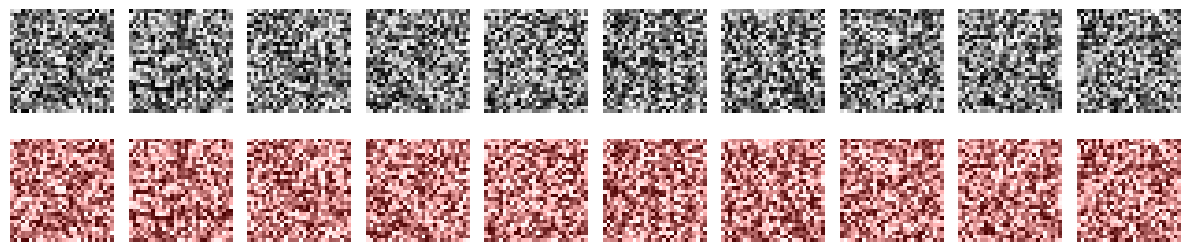

In [6]:
# Parameters
B, W, H, C = 10, 28, 28, 3

# 1) Generate 10 black-and-white random noise images
# Shape: (B, W, H)
bw = np.random.rand(B, W, H)

# Convert to RGB by repeating the grayscale channel
# Shape: (B, W, H, 3)
images = np.repeat(bw[..., None], 3, axis=-1)

# 2) Create a single red image to add
# Shape: (W, H, 3)
single_red = np.zeros((W, H, 3))
single_red[..., 0] = 0.3  # add red

# 3) Broadcasting addition
images_plus_red = np.clip(images + single_red, 0.0, 1.0)

# 4) Visualize (top: original, bottom: after adding red)
fig, axes = plt.subplots(2, B, figsize=(B * 1.2, 3))

for i in range(B):
    axes[0, i].imshow(images[i])
    axes[0, i].axis("off")
    axes[1, i].imshow(images_plus_red[i])
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()


# Advanced Usage

For Basic usage, just ask LLM or look at the documentation, here we cover more interesting usages.

## Is vectorize always good enough?

Vectorization is usually the **first and best tool** in NumPy. It replaces Python loops with fast, compiled C code and often leads to dramatic speedups.

However, vectorization is **not always optimal**.

Consider the following practical task, applied **row-wise** to a matrix  

For each row $x$ of a matrix $X \in \mathbb{R}^{N \times D}$
1. Compute mean $\mu$
2. Compute standard devviation $\sigma$
3. Normalize $(x - \mu) / \sigma$
4. Count how many normalized values exceed a threshold $\tau$

In [7]:
def numpy_version_loop(X, thresh=1.0):
    N, D = X.shape
    out = np.zeros(N, dtype=np.int32)

    for i in range(N):
        # mean
        mu = 0.0
        for j in range(D):
            mu += X[i, j]
        mu /= D

        # std
        var = 0.0
        for j in range(D):
            diff = X[i, j] - mu
            var += diff * diff
        std = np.sqrt(var / D) + 1e-12

        # normalize + count
        cnt = 0
        for j in range(D):
            z = (X[i, j] - mu) / std
            if z > thresh:
                cnt += 1

        out[i] = cnt

    return out

In [8]:


def numpy_version(X, thresh=1.0):
    mu = X.mean(axis=1, keepdims=True)          # pass 1
    std = X.std(axis=1, keepdims=True) + 1e-12  # pass 2
    Z = (X - mu) / std                          # pass 3 (alloc)
    return (Z > thresh).sum(axis=1)             # pass 4



This code is clear, concise, and mathematically faithful.
However, notice that the code
- Make multiple full passes over $X$,
- Allocate intermediate arrays
- Move a large amount of data through memory
For large $N, D$, this computation becomes memory-bandwidth bound rather than compute-bound.

With Numba, we can keep the mathematical logic but fuse all steps into a single compiled loop, avoiding temporary arrays.

In [9]:
from numba import njit
import numpy as np

@njit(parallel=True, cache=True)
def numba_version(X, thresh=1.0):
    N, D = X.shape
    out = np.zeros(N, dtype=np.int32)

    for i in range(N):
        # mean
        mu = 0.0
        for j in range(D):
            mu += X[i, j]
        mu /= D

        # std
        var = 0.0
        for j in range(D):
            diff = X[i, j] - mu
            var += diff * diff
        std = np.sqrt(var / D) + 1e-12

        # normalize + count
        cnt = 0
        for j in range(D):
            z = (X[i, j] - mu) / std
            if z > thresh:
                cnt += 1

        out[i] = cnt

    return out


In [10]:
import time

N, D = 50000, 512
X = np.random.randn(N, D).astype(np.float64)

numba_version(X[:50])  # warm-up numba --- IGNORE ---


t0 = time.perf_counter()
a = numpy_version(X)
t1 = time.perf_counter()


b = numba_version(X)
t2 = time.perf_counter()

c = numpy_version_loop(X)
t3 = time.perf_counter()



print(f"NumPy vectorized: {t1 - t0:.4f}")
print(f"Numba loop: {t2 - t1:.4f}")
print(f"NumPy loop: {t3 - t2:.4f}")
print(f"max diff: {np.max(np.abs(a - b))}")

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


NumPy vectorized: 0.6260
Numba loop: 0.0989
NumPy loop: 18.7219
max diff: 0



## When Numpy Wins?

### Gram matrix

Consider the data matrix $X = [x_1, x_2, \cdots, x_N]^\top \in \mathbb{R}^{N \times D}$
we compute the pairwise data similarity:
$$G = X X^\top$$
For the entry-wise expression:
$$G_{ij} = x_i^\top x_j$$

In [11]:
from numba import njit, prange
import numpy as np

def gram_numpy(X):
    return X @ X.T


@njit(parallel=True, fastmath=True)
def gram_numba(X):
    N, D = X.shape
    G = np.zeros((N, N), dtype=X.dtype)
    for i in prange(N):
        for j in range(N):
            s = 0.0
            for k in range(D):
                s += X[i, k] * X[j, k]
            G[i, j] = s
    return G

In [12]:
import time

N, D = 5000, 512
X = np.random.randn(N, D).astype(np.float64)

# warm up numba
gram_numba(X[:50])

t0 = time.perf_counter()
G1 = gram_numpy(X)
t1 = time.perf_counter()

G2 = gram_numba(X)
t2 = time.perf_counter()

print(f"NumPy GEMM: {t1 - t0:.4f}")
print(f"Numba loops: {t2 - t1:.4f}")
print(f"max diff: {np.max(np.abs(G1 - G2))}")

NumPy GEMM: 0.2225
Numba loops: 1.0283
max diff: 6.821210263296962e-13


Use **Numpy** when:
- it's expressible as `@ / linalg.*`
- it's a few ufuncs and reductions

Use **Numba** when:
- You have nested loops, irregular indexing, conditionals
- You see many intermediates in Numpy and want to fuse
- You can early-exit / skip work
- You're bulding histograms / co-occurrence / custom kernels

# Einsum

Many NumPy programs consist of **linear algebra written indirectly**:
matrix multiplications, reductions over axes, tensor contractions, and
pairwise interactions. These are often expressed using combinations of
`reshape`, `transpose`, `sum`, and `@`, which can obscure the underlying math.

`np.einsum` (Einstein summation) provides a way to write **the mathematical
expression itself**, and let NumPy decide how to execute it efficiently.

In [13]:
x = np.array([1, 2, 3, 4])
w = np.array([0.1, 0.2, 0.3, 0.4])
y_ein = np.einsum("i,i -> ", x, w)
y_dot = np.dot(x, w)    
print("einsum result:", y_ein)
print("dot result:", y_dot)

einsum result: 3.0
dot result: 3.0


In [14]:
X1 = np.array([[1, 2, 3],
               [4, 5, 6],
               [7, 8, 9]])
X2 = np.array([[7, 8, 9],
               [10, 11, 12],
               [13, 14, 15]])
Y_ein = np.einsum("ik,kj->ij", X1, X2)
Y_prod = X1 @ X2
print("einsum result:\n", Y_ein)
print("matrix product result:\n", Y_prod)

einsum result:
 [[ 66  72  78]
 [156 171 186]
 [246 270 294]]
matrix product result:
 [[ 66  72  78]
 [156 171 186]
 [246 270 294]]


### Covariance of sequence embedding
Recall the emprical covaraince matrix (Gram)
$$XX^\top$$
Given token embedding $X \in \mathbb{R}^{B \times N \times D}$, we want to compute per-batch covariance
$$ \Sigma_{b, i, j} = \frac{1}{N} \sum_{n} X_{b,n,i} X_{b,n,j} $$

In [15]:
X = np.random.randn(5, 10, 3)
Sigma = np.einsum("bti,btj->bij", X, X) / X.shape[1]
print("Covariance shape:", Sigma.shape)

Covariance shape: (5, 3, 3)


# Row-wise vs. column-wise Speed (memory layout matters)

NumPy is row-major (C-order) by default; traversing contiguous memory (row, so column sum) is faster.


In [16]:
import time
A = np.random.randn(10000, 10000).astype(np.float64)

# Row-wise reduction (contiguous along last axis)
t0 = time.perf_counter()
r = A.sum(axis=1)
t1 = time.perf_counter()

# Column-wise reduction (strided access)
t2 = time.perf_counter()
c = A.sum(axis=0)
t3 = time.perf_counter()

print("row-wise sum:", t1 - t0)
print("col-wise sum:", t3 - t2)


row-wise sum: 0.2737207500031218
col-wise sum: 0.023093833005987108


# Principal of Numpy

A realization of linear algebra, have to understand the math first!

## Distance Matrix

Given $X = [x_1, x_2, \cdots, x_N]^\top \in \mathbb{R}^{N \times D}$, compute
$$D_{ij} = \| x_i - x_j \|_2^2$$
Naively this is $O(N^2D)$ with loop

**Math Simplification**: Use the identity
$$ \| x_i - x_j \|^2 = \| x_i \|^2 + \|x_j \|^2 - 2 x_i^\top x_j $$
Let $s \in \mathbb{R}^N$ be the vector of row norms squared:
$$ s_i = \|x_i\|^2 $$
Then the whole distance matrix is
$$ D = s \mathbb{1}^\top + \mathbb{1} s^\top - 2 X X^\top $$

In [ ]:
import numpy as np

def pairwise_sq_dists(X):
    # X: (N, D)
    s = np.sum(X * X, axis=1, keepdims=True)   # (N, 1), s_i = ||x_i||^2
    # broadcating s to into shape of (N, N)
    D = s + s.T - 2 * (X @ X.T)               
    return D

X = np.array([[10, 0, 1], [0, 10, 1], [0, 0, 1]])
D = pairwise_sq_dists(X)
print("Pairwise squared distances:\n", D)

Pairwise squared distances:
 [[  0 200 100]
 [200   0 100]
 [100 100   0]]


## Attention

In NLP, we use a vector to represent a meaning of word. consider the sentence "Bank of the River", we use 3d vector [Finance, Nature, Preposition] to represent 4 words:
- Bank: [5, 5, 0]
- of: [0, 0, 10]
- the: [0, 0, 10]
- River: [0, 10, 0]
So this is again a matrix

In [18]:
X = np.array([
    [5, 5, 0],
    [0, 0, 10],
    [0, 0, 10],
    [0, 10, 0]
])

We want to represent each word in the context of this sentence. A natural idea is to make each word attend every word (cosine similarity), and reweight the each dimension, this is exactly self-attention mechanism
$$
\operatorname{Softmax}(\frac{QK^\top}{\sqrt{d}}) V
$$
we let $X = Q = K = V$

In [19]:
def softmax(X):
    e_X = np.exp(X)
    return e_X / e_X.sum(axis=-1, keepdims=True)

def self_attention(X):
    # X: (N, D)
    Q = X  # (N, D)
    K = X  # (N, D)
    V = X  # (N, D)
    scores = np.dot(Q, K.T) 
    weights = softmax(scores)
    return weights @ V  # (N, D)    

print("Input X:\n", X)
attn_output = self_attention(X)
print("Self-attention output:\n", attn_output)

Input X:
 [[ 5  5  0]
 [ 0  0 10]
 [ 0  0 10]
 [ 0 10  0]]
Self-attention output:
 [[2.50000000e+00 7.50000000e+00 1.92874985e-21]
 [9.30018994e-44 2.79005698e-43 1.00000000e+01]
 [9.30018994e-44 2.79005698e-43 1.00000000e+01]
 [9.64374924e-22 1.00000000e+01 7.44015195e-43]]


In [20]:
# Feature of Bank
print("feature of bank:\n", attn_output[0])

feature of bank:
 [2.50000000e+00 7.50000000e+00 1.92874985e-21]


This is more likely to represent "nature"!